In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv(r'clean_titanic.csv')
df.set_index('PassengerId', inplace=True)

In [3]:
df.head(1)

,Survived,Pclass,Name,Sex,Age,Sibling/Spouse,Parent/Child,Ticket,Ticket_fare,Embarked
PassengerId,,,,,,,,,,
1,0,3rd,"Braund, Mr. Owen Harris",male,22,1,0,A/5 21171,7.25,S


## GroupBy

In [4]:
survive = df.groupby('Survived') #object of DataFrameGroupBy 
survive

<Axes: >

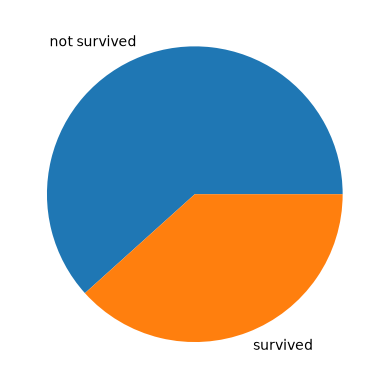

In [5]:
survive['Pclass'].unique()
survive['Ticket_fare'].sum()
survive['Pclass'].count()
a = survive['Pclass'].count()
a.index = ['not survived', 'survived']
a.name = 'Titanic Survived data'
a.plot(kind='pie')

In [6]:
imdb = pd.read_csv('imdb_top_1000.csv')
imdb.head(1)

,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross
0,https://m.media-amazon.com/images/M/MV5BMDFkYT...,The Shawshank Redemption,1994,A,142 min,Drama,9.3,Two imprisoned men bond over a number of years...,80.0,Frank Darabont,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler,2343110,"28,341,469"


In [7]:
imdb.groupby('Released_Year')['Series_Title'].count()['1994']
imdb.groupby('Released_Year')['Series_Title'].count().sort_values().head(1)
imdb.groupby('Released_Year')['Series_Title'].count().sort_values().tail(1)
imdb.groupby('Released_Year')['Series_Title'].count().std()
imdb.groupby('Released_Year')['Series_Title'].count()['2019']

np.int64(23)

In [8]:
imdb.groupby('Genre')['IMDB_Rating'].max().sort_values(ascending=False).head(1)

Genre
Drama    9.3
Name: IMDB_Rating, dtype: float64

In [9]:
imdb.groupby('Director')['No_of_Votes'].sum().sort_values(ascending=False)

Director
Christopher Nolan    11578345
Quentin Tarantino     8123208
Steven Spielberg      7817166
David Fincher         6607859
Martin Scorsese       6513530
                       ...   
J. Lee Thompson         26457
Peter Mullan            25938
René Laloux             25229
Francis Lee             25198
Kaige Chen              25088
Name: No_of_Votes, Length: 548, dtype: int64

In [10]:
imdb2 = imdb.dropna(subset=['Gross'])

In [11]:
imdb2['Gross'] = list(map(lambda x:int(str(x).replace(',','')),  imdb2['Gross']))

In [12]:
imdb2.groupby('Series_Title')['Gross'].max().sort_values(ascending=False).head(1)

Series_Title
Star Wars: Episode VII - The Force Awakens    936662225
Name: Gross, dtype: int64

In [13]:
imdb3 = imdb.dropna(subset=['Gross'])
imdb3.Gross

0       28,341,469
1      134,966,411
2      534,858,444
3       57,300,000
4        4,360,000
          ...     
990        696,690
991      1,378,435
992    141,843,612
994     13,780,024
997     30,500,000
Name: Gross, Length: 831, dtype: str

In [14]:
imdb3['Gross'] = imdb3['Gross'].str.replace(',', '').astype('int64')

In [15]:
imdb3['Gross']

0       28341469
1      134966411
2      534858444
3       57300000
4        4360000
         ...    
990       696690
991      1378435
992    141843612
994     13780024
997     30500000
Name: Gross, Length: 831, dtype: int64

#### Get data of a group

In [17]:
genre = imdb.groupby('Genre')
genre

In [20]:
imdb['Genre'].unique()

<StringArray>
[                     'Drama',               'Crime, Drama',
       'Action, Crime, Drama',   'Action, Adventure, Drama',
  'Biography, Drama, History',  'Action, Adventure, Sci-Fi',
             'Drama, Romance',                    'Western',
             'Action, Sci-Fi',    'Biography, Crime, Drama',
 ...
     'Action, Adventure, War',     'Drama, Horror, Mystery',
   'Animation, Comedy, Crime',   'Action, Adventure, Crime',
 'Action, Adventure, Mystery',  'Action, Adventure, Family',
     'Action, Crime, Mystery',  'Animation, Drama, Romance',
        'Drama, War, Western',     'Adventure, Comedy, War']
Length: 202, dtype: str

In [26]:
genre.get_group('Drama')['Series_Title']

0             The Shawshank Redemption
9                           Fight Club
17     One Flew Over the Cuckoo's Nest
20                     Soorarai Pottru
40                  American History X
                    ...               
933               Synecdoche, New York
934                    Mysterious Skin
941                          25th Hour
946                  Y tu mamá también
981                     On Golden Pond
Name: Series_Title, Length: 85, dtype: str

In [33]:
dg = imdb.groupby(['Director','Genre'])

In [38]:
dg['Series_Title'].count().sort_values()

Director              Genre                       
Aamir Khan            Drama, Family                   1
Aaron Sorkin          Drama, History, Thriller        1
Abdellatif Kechiche   Drama, Romance                  1
Abhishek Chaubey      Action, Crime, Drama            1
Abhishek Kapoor       Drama, Sport                    1
                                                     ..
Richard Linklater     Drama, Romance                  3
Martin Scorsese       Biography, Crime, Drama         3
Paul Thomas Anderson  Drama                           3
Sergio Leone          Western                         3
Pete Docter           Animation, Adventure, Comedy    4
Name: Series_Title, Length: 912, dtype: int64

In [42]:
dg.get_group(('Pete Docter', 'Animation, Adventure, Comedy'))

,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross
146,https://m.media-amazon.com/images/M/MV5BMTk3ND...,Up,2009,U,96 min,"Animation, Adventure, Comedy",8.2,78-year-old Carl Fredricksen travels to Paradi...,88.0,Pete Docter,Bob Peterson,Edward Asner,Jordan Nagai,John Ratzenberger,935507,"293,004,164"
205,https://m.media-amazon.com/images/M/MV5BZGE1MD...,Soul,2020,U,100 min,"Animation, Adventure, Comedy",8.1,"After landing the gig of a lifetime, a New Yor...",83.0,Pete Docter,Kemp Powers,Jamie Foxx,Tina Fey,Graham Norton,159171,NaN
213,https://m.media-amazon.com/images/M/MV5BOTgxMD...,Inside Out,2015,U,95 min,"Animation, Adventure, Comedy",8.1,After young Riley is uprooted from her Midwest...,94.0,Pete Docter,Ronnie Del Carmen,Amy Poehler,Bill Hader,Lewis Black,616228,"356,461,711"
245,https://m.media-amazon.com/images/M/MV5BMTY1NT...,"Monsters, Inc.",2001,U,92 min,"Animation, Adventure, Comedy",8.1,"In order to power the city, monsters have to s...",79.0,Pete Docter,David Silverman,Lee Unkrich,Billy Crystal,John Goodman,815505,"289,916,256"
